# Full Reserving Workflow and Method Comparison

Data sources used:
- `.../chainladder-python/chainladder/utils/data/friedland_us_industry_auto.csv`
- `.../chainladder-python/chainladder/utils/data/friedland_xyz_freq_sev.csv`

Learning goals:
- Show the end-to-end workflow: data preparation -> development -> tail -> method -> ultimate/IBNR.
- Compare deterministic reserving estimators under a consistent API/workflow.
- Cover evaluation of methods: expected emergence between dates, interpolation, and handling IBNR discrepancies.


In [60]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from IPython.display import display

try:
    import chainladder as cl
except Exception as exc:  # pragma: no cover - notebook guard
    raise RuntimeError(
        "chainladder import failed. Activate the project environment (for example .venv_exam5) before running this notebook."
    ) from exc

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent

MAIN_DATA_PATH = ROOT / 'chainladder-python' / 'chainladder' / 'utils' / 'data' / 'friedland_us_industry_auto.csv'
FREQ_SEV_DATA_PATH = ROOT / 'chainladder-python' / 'chainladder' / 'utils' / 'data' / 'friedland_xyz_freq_sev.csv'

raw_main = pd.read_csv(MAIN_DATA_PATH)
triangle_main = cl.Triangle(
    raw_main,
    origin='Accident Year',
    development='Calendar Year',
    columns=['Paid Claims', 'Reported Claims'],
    cumulative=True,
)

paid_triangle = triangle_main['Paid Claims']
reported_triangle = triangle_main['Reported Claims']

triangle_main


,Triangle Summary
Valuation:,2007-12
Grain:,OYDY
Shape:,"(1, 2, 10, 10)"
Index:,[Total]
Columns:,"[Paid Claims, Reported Claims]"


## Methods   

Methods consume a triangle (typically cumulative) plus fitted development/tail structure and produce ultimates and IBNR.

General pattern:  
`model = cl.SomeMethod(...).fit(tri)`  
`ultimate = model.ultimate_`  
`ibnr = model.ibnr_`  
`latest = model.X_.latest_diagonal`  

`ultimate`, `ibnr`, and `latest_diagonal` are triangle-shaped outputs aligned with the input.  

### a. Chain Ladder  

Purely development-driven.
 
Assumptions:  
- past development pattern repeats  
- no calendar-year distortion  
- cumulative triangle input  

Core relationship:  
`Ultimate = LatestDiagonal * CDF`  
 
### b. Expected Loss  

Equivalent to Benktander with zero iterations.   
Relies on externally selected expected loss (for example ELR x exposure).  
Ignores observed development in the blending step.  
Used when triangle experience is not fully credible.  
 
### c. Bornhuetter-Ferguson (BF)  

Blends expected loss with observed development.  

Core idea:  
`Ultimate = Reported + ExpectedUnreported`  

Where:  
`ExpectedUnreported = ExpectedUltimate * (1 - PercentReported)`  

### d. Benktander  

Iterative refinement between Expected Loss and Chain Ladder.  
Interpretation shifts weight from expected loss toward observed development as maturity increases.  

At:  
- `0` iterations -> Expected Loss  
- `1` iteration -> BF  
- many iterations -> Chain Ladder limit  

### e. Cape Cod  

Data-driven ELR method.  
Uses exposure base but derives expected loss ratio from the triangle itself.  
Blends development pattern and exposure weighting.  

### f. Case Outstanding  

Uses case reserve information to estimate remaining development.  
Separates reported-but-unpaid behavior from pure IBNR dynamics.  
 
### g. Frequency-Severity  

Separates claim count and average severity.  
Projects each component, then recombines:  
`UltimateLoss = UltimateCount * UltimateSeverity`  


In [61]:
def fit_workflow(
    tri: cl.Triangle,
    method_estimator,
    sample_weight: cl.Triangle | None = None,
    dev_average: str = 'volume',
    tail_factor: float = 1.02,
):
    pipe = cl.Pipeline(
        steps=[
            ('development', cl.Development(average=dev_average)),
            ('tail', cl.TailConstant(tail=tail_factor)),
            ('method', method_estimator),
        ]
    )
    if sample_weight is None:
        pipe.fit(tri)
    else:
        pipe.fit(tri, sample_weight=sample_weight)
    return pipe

# Prior/Exposure proxies for methods that need sample_weight.
# For BF/Benktander/ExpectedLoss, treat this as an apriori-ultimate proxy.
apriori_ultimate = paid_triangle.latest_diagonal * 1.30

# For Cape Cod, treat latest diagonal as an exposure proxy in this educational example.
cape_cod_exposure = paid_triangle.latest_diagonal.copy()

workflow_methods = {
    'Chainladder': (cl.Chainladder(), None),
    'ExpectedLoss': (cl.ExpectedLoss(apriori=1.0), apriori_ultimate),
    'BornhuetterFerguson': (cl.BornhuetterFerguson(apriori=1.0), apriori_ultimate),
    'Benktander_n2': (cl.Benktander(apriori=1.0, n_iters=2), apriori_ultimate),
    'CapeCod': (cl.CapeCod(trend=0.0, decay=1.0), cape_cod_exposure),
}

workflow_fits: dict[str, cl.Pipeline] = {}
for method_name, (method_estimator, sw) in workflow_methods.items():
    workflow_fits[method_name] = fit_workflow(
        tri=paid_triangle,
        method_estimator=method_estimator,
        sample_weight=sw,
        dev_average='volume',
        tail_factor=1.02,
    )

latest_total = float(paid_triangle.latest_diagonal.sum().sum())

method_summary_rows = []
for method_name, fit_obj in workflow_fits.items():
    method_model = fit_obj.named_steps['method']
    total_ultimate = float(method_model.ultimate_.sum().sum())
    total_ibnr = float(method_model.ibnr_.sum().sum())
    method_summary_rows.append(
        {
            'Method': method_name,
            'Latest': latest_total,
            'Ultimate': total_ultimate,
            'IBNR': total_ibnr,
            'Ultimate_to_Latest': total_ultimate / latest_total,
        }
    )

method_summary = pd.DataFrame(method_summary_rows).set_index('Method').sort_values('Ultimate')
method_summary


,Latest,Ultimate,IBNR,Ultimate_to_Latest
Method,,,,
CapeCod,"498,050,368.00","557,998,892.46","59,948,524.46",1.12
BornhuetterFerguson,"498,050,368.00","567,610,721.24","69,560,353.24",1.14
Benktander_n2,"498,050,368.00","572,526,289.70","74,475,921.70",1.15
Chainladder,"498,050,368.00","584,378,559.24","86,328,191.24",1.17
ExpectedLoss,"498,050,368.00","647,465,478.40","149,415,110.40",1.30


## 6. Workflow

The workflow formalizes reserving as composable steps:
`data prep -> development -> tail -> method -> evaluation`

This keeps transformation separate from projection and makes model swapping straightforward.

### a. Pipeline Structure

Typical reserving pipeline:

```python
cl.Pipeline([
    ('development', cl.Development(...)),
    ('tail', cl.TailCurve(...) or cl.TailConstant(...)),
    ('method', cl.Chainladder() or other method),
])
```

Each step receives a triangle (or fitted object from prior step) and returns transformed or fitted output.

### b. Fit/Predict Logic

- `fit()` estimates step parameters.
- `predict()`/attributes from the method step produce ultimate and IBNR.
- Intermediate fitted objects remain accessible through `named_steps`.


In [62]:
chainladder_workflow = workflow_fits['Chainladder']

selected_dev = chainladder_workflow.named_steps['development']
selected_tail = chainladder_workflow.named_steps['tail']
selected_method = chainladder_workflow.named_steps['method']

ldf_preview = selected_dev.ldf_.to_frame().iloc[:, :5]
cdf_preview = selected_tail.cdf_.to_frame().iloc[:, :5]
ultimate_preview = selected_method.ultimate_.to_frame().head()

print('Development LDF preview:')
display(ldf_preview)
print('Tail CDF preview:')
display(cdf_preview)
print('Ultimate preview (Chainladder workflow):')
display(ultimate_preview)


Development LDF preview:


,12-24,24-36,36-48,48-60,60-72
(All),1.73,1.19,1.09,1.04,1.02


Tail CDF preview:


,12-Ult,24-Ult,36-Ult,48-Ult,60-Ult
(All),2.49,1.44,1.21,1.11,1.06


Ultimate preview (Chainladder workflow):


,2261
1998-01-01,"48,597,070.74"
1999-01-01,"52,117,606.83"
2000-01-01,"55,858,204.02"
2001-01-01,"57,509,788.56"
2002-01-01,"60,061,835.21"


### c. Model Comparison in the Same Workflow

Because the API is consistent, we can swap only the method step while keeping development and tail setup fixed.

This supports structured comparison across:
- reserving methods,
- development assumptions,
- tail assumptions.


In [63]:
ultimate_by_origin = {
    method_name: fit_obj.named_steps['method'].ultimate_.to_frame().iloc[:, 0]
    for method_name, fit_obj in workflow_fits.items()
}

ultimate_origin_compare = pd.DataFrame(ultimate_by_origin)
ultimate_origin_compare['Range_MaxMinusMin'] = (
    ultimate_origin_compare.max(axis=1) - ultimate_origin_compare.min(axis=1)
)

total_compare = ultimate_origin_compare.sum().to_frame(name='Total Across Origins')

print('Ultimate by origin and method:')
display(ultimate_origin_compare)

print('Totals by method:')
display(total_compare)


Ultimate by origin and method:


,Chainladder,ExpectedLoss,BornhuetterFerguson,Benktander_n2,CapeCod,Range_MaxMinusMin
1998-01-01,"48,597,070.74","61,937,443.10","48,858,646.67","48,602,199.68","48,690,833.00","13,340,372.36"
1999-01-01,"52,117,606.83","66,300,694.20","52,421,602.79","52,124,122.59","52,225,239.93","14,183,087.37"
2000-01-01,"55,858,204.02","70,893,192.50","56,214,839.98","55,866,663.57","55,982,474.92","15,034,988.48"
2001-01-01,"57,509,788.56","72,641,947.30","57,939,039.19","57,521,965.02","57,654,303.58","15,132,158.74"
2002-01-01,"60,061,835.21","75,149,379.50","60,628,196.23","60,083,095.45","60,238,393.89","15,087,544.29"
2003-01-01,"59,210,652.16","72,709,850.20","59,958,445.72","59,252,076.48","59,401,886.67","13,499,198.04"
2004-01-01,"59,427,751.51","69,907,073.60","60,424,599.61","59,522,576.93","59,505,714.60","10,479,322.09"
2005-01-01,"61,078,106.12","65,838,492.20","61,891,255.79","61,217,005.02","60,337,250.70","5,501,241.50"
2006-01-01,"62,674,106.43","56,688,446.10","60,853,063.58","62,120,082.84","58,469,938.18","5,985,660.33"
2007-01-01,"67,843,437.66","35,398,959.70","48,421,031.69","56,216,502.12","45,492,856.99","32,444,477.96"


Totals by method:


,Total Across Origins
Chainladder,"584,378,559.24"
ExpectedLoss,"647,465,478.40"
BornhuetterFerguson,"567,610,721.24"
Benktander_n2,"572,526,289.70"
CapeCod,"557,998,892.46"
Range_MaxMinusMin,"140,688,051.16"


### Visual: Method Projections by AY

This view compares all method ultimates by accident year (AY):
- top panel: clustered bars of absolute ultimate projections,
- bottom panel: each method indexed to Chainladder (`Chainladder = 100`) to highlight relative differences by AY.


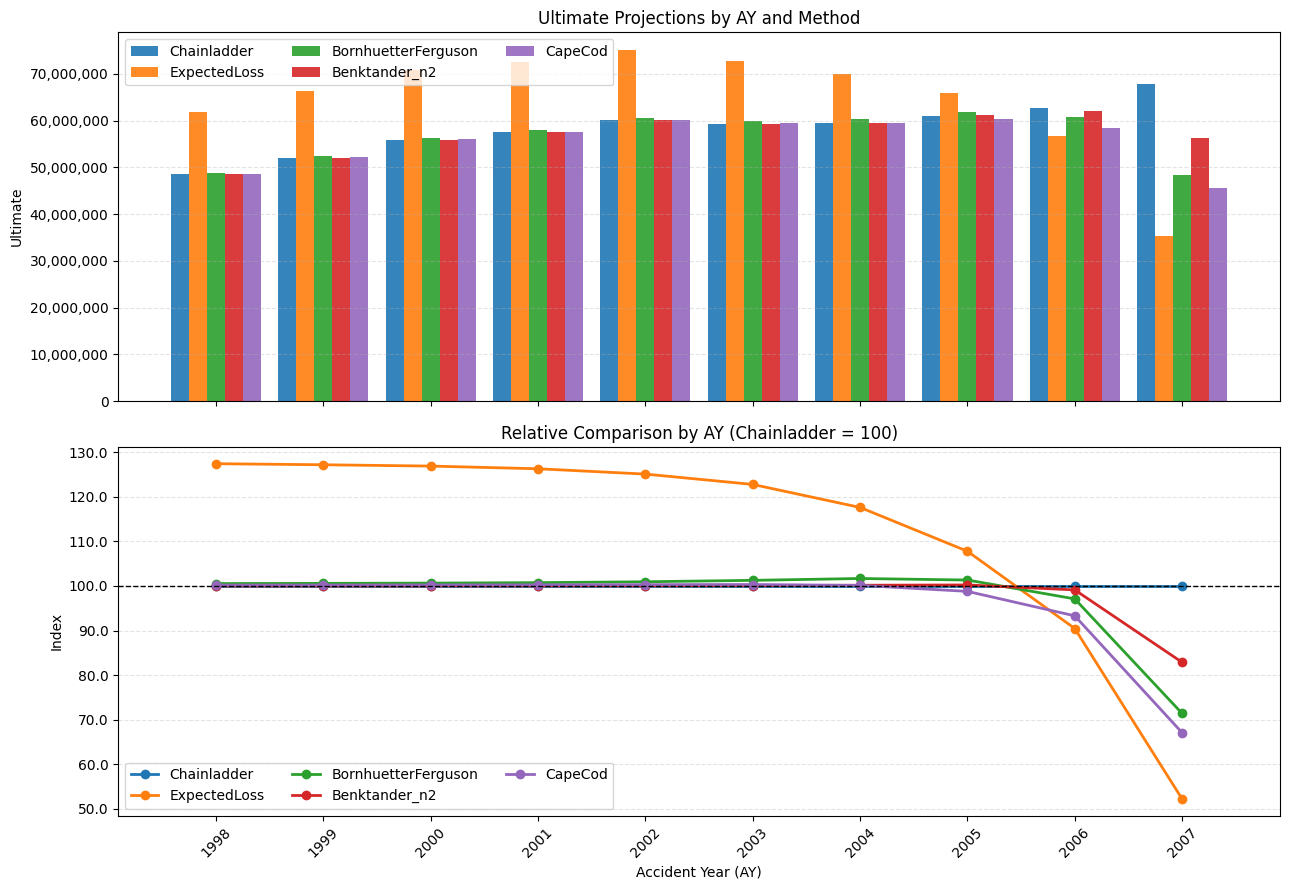

,Chainladder,ExpectedLoss,BornhuetterFerguson,Benktander_n2,CapeCod
1998,"48,597,070.74","61,937,443.10","48,858,646.67","48,602,199.68","48,690,833.00"
1999,"52,117,606.83","66,300,694.20","52,421,602.79","52,124,122.59","52,225,239.93"
2000,"55,858,204.02","70,893,192.50","56,214,839.98","55,866,663.57","55,982,474.92"
2001,"57,509,788.56","72,641,947.30","57,939,039.19","57,521,965.02","57,654,303.58"
2002,"60,061,835.21","75,149,379.50","60,628,196.23","60,083,095.45","60,238,393.89"
2003,"59,210,652.16","72,709,850.20","59,958,445.72","59,252,076.48","59,401,886.67"
2004,"59,427,751.51","69,907,073.60","60,424,599.61","59,522,576.93","59,505,714.60"
2005,"61,078,106.12","65,838,492.20","61,891,255.79","61,217,005.02","60,337,250.70"
2006,"62,674,106.43","56,688,446.10","60,853,063.58","62,120,082.84","58,469,938.18"
2007,"67,843,437.66","35,398,959.70","48,421,031.69","56,216,502.12","45,492,856.99"


,Chainladder,ExpectedLoss,BornhuetterFerguson,Benktander_n2,CapeCod
1998,100.00,127.45,100.54,100.01,100.19
1999,100.00,127.21,100.58,100.01,100.21
2000,100.00,126.92,100.64,100.02,100.22
2001,100.00,126.31,100.75,100.02,100.25
2002,100.00,125.12,100.94,100.04,100.29
2003,100.00,122.80,101.26,100.07,100.32
2004,100.00,117.63,101.68,100.16,100.13
2005,100.00,107.79,101.33,100.23,98.79
2006,100.00,90.45,97.09,99.12,93.29
2007,100.00,52.18,71.37,82.86,67.06


In [64]:
# Build plotting frame from the method comparison table created above.
method_order = list(workflow_fits.keys())
plot_df = ultimate_origin_compare[method_order].copy()
ay_labels = plot_df.index.year.astype(str)
plot_df.index = ay_labels

# Relative index for easier shape comparison across methods.
relative_df = plot_df.div(plot_df['Chainladder'], axis=0) * 100.0

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# Top: clustered bars (absolute ultimate).
x = np.arange(len(plot_df.index))
n_methods = len(method_order)
total_width = 0.84
bar_width = total_width / n_methods
offset_start = -total_width / 2 + bar_width / 2

for i, method in enumerate(method_order):
    ax1.bar(
        x + offset_start + i * bar_width,
        plot_df[method].values,
        width=bar_width,
        label=method,
        alpha=0.9,
    )

ax1.set_title('Ultimate Projections by AY and Method')
ax1.set_ylabel('Ultimate')
ax1.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.35)
ax1.legend(ncol=3, loc='upper left')

# Bottom: indexed-to-Chainladder lines.
for method in method_order:
    ax2.plot(
        plot_df.index,
        relative_df[method],
        marker='o',
        linewidth=2,
        label=method,
    )

ax2.axhline(100.0, color='black', linestyle='--', linewidth=1)
ax2.set_title('Relative Comparison by AY (Chainladder = 100)')
ax2.set_ylabel('Index')
ax2.set_xlabel('Accident Year (AY)')
ax2.yaxis.set_major_formatter(StrMethodFormatter('{x:,.1f}'))
ax2.grid(axis='y', linestyle='--', alpha=0.35)
ax2.legend(ncol=3, loc='best')

ax2.set_xticks(plot_df.index)
ax2.set_xticklabels(plot_df.index, rotation=45)

plt.tight_layout()
plt.show()

display(plot_df)
display(relative_df)


## Evaluating Reserving Techniques (from formula-sheet layout)

For this section, expected emergence is calculated directly from the fitted model's `full_expectation_` attribute.

Backtest setup:
- fit the workflow using data only through the prior valuation date,
- use `full_expectation_` to project the next calendar year's expected emergence,
- compare that expected emergence against actual observed emergence from the held-out year.

This produces an AY-level Actual vs Expected comparison using the same workflow structure.


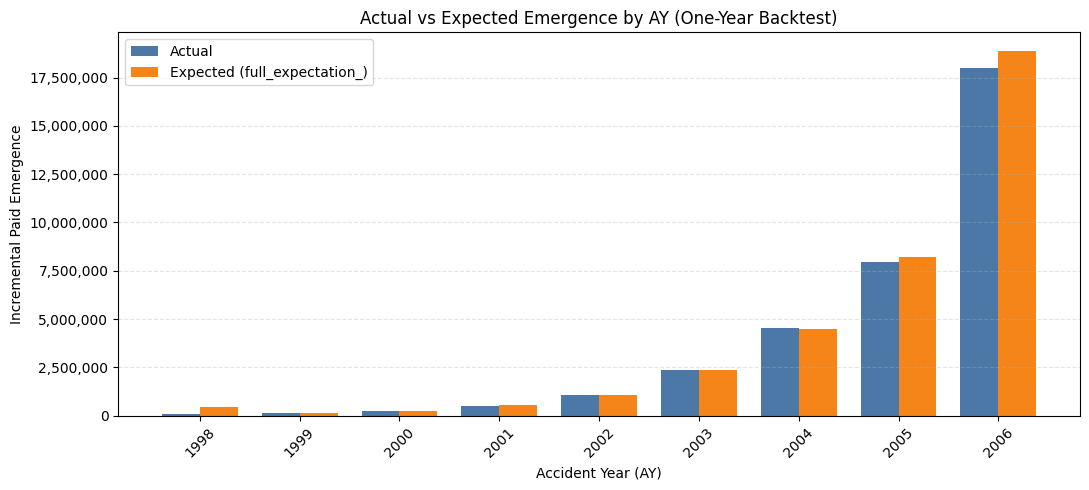

Backtest window: 2006-12-31 -> 2007-12-31


,Actual,Expected
1998,"88,731.00","467,793.75"
1999,"121,726.00","116,432.74"
2000,"248,891.00","265,524.61"
2001,"499,620.00","538,046.07"
2002,"1,052,839.00","1,078,533.02"
2003,"2,346,453.00","2,354,039.87"
2004,"4,537,994.00","4,486,737.73"
2005,"7,942,765.00","8,226,897.32"
2006,"17,997,721.00","18,894,842.86"
2007,"27,229,969.00",NaN


In [65]:
# Backtest one-year emergence using full_expectation_ (expected) vs actual observed emergence.
current_valuation = paid_triangle.valuation_date
prior_valuation = current_valuation - pd.DateOffset(years=1)

history_paid = paid_triangle[paid_triangle.valuation <= prior_valuation]
history_fit = fit_workflow(
    tri=history_paid,
    method_estimator=cl.Chainladder(),
    dev_average='volume',
    tail_factor=1.02,
)
history_model = history_fit.named_steps['method']

expected_runoff = history_model.full_expectation_.dev_to_val().cum_to_incr()
actual_runoff = paid_triangle.dev_to_val().cum_to_incr()

expected_1y = expected_runoff[(expected_runoff.valuation > prior_valuation) & (expected_runoff.valuation <= current_valuation)]
actual_1y = actual_runoff[(actual_runoff.valuation > prior_valuation) & (actual_runoff.valuation <= current_valuation)]

expected_by_ay = expected_1y.to_frame().iloc[:, 0].rename('Expected')
actual_by_ay = actual_1y.to_frame().iloc[:, 0].rename('Actual')

ay_actual_expected = pd.concat([actual_by_ay, expected_by_ay], axis=1)
ay_actual_expected.index = ay_actual_expected.index.year.astype(str)

# Keep only AYs with both actual and expected for a clean side-by-side backtest chart.
ay_chart = ay_actual_expected.dropna(subset=['Actual', 'Expected']).copy()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(ay_chart))
width = 0.38
ax.bar(x - width / 2, ay_chart['Actual'], width=width, label='Actual', color='#4C78A8')
ax.bar(x + width / 2, ay_chart['Expected'], width=width, label='Expected (full_expectation_)', color='#F58518')

ax.set_title('Actual vs Expected Emergence by AY (One-Year Backtest)')
ax.set_xlabel('Accident Year (AY)')
ax.set_ylabel('Incremental Paid Emergence')
ax.set_xticks(x)
ax.set_xticklabels(ay_chart.index, rotation=45)
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

print(f'Backtest window: {prior_valuation.date()} -> {current_valuation.date()}')
display(ay_actual_expected)


## Additional Method Views: Case Outstanding and Frequency-Severity

These align with the methods summary in the workflow sheet and are useful comparators.


In [66]:
# Case Outstanding demonstration (uses paid/incurred relationship)
usauto = cl.load_sample('usauto')
co_dev = cl.CaseOutstanding(paid_to_incurred=('paid', 'incurred')).fit(usauto)
co_adjusted = co_dev.transform(usauto)
co_paid_method = cl.Chainladder().fit(co_adjusted['paid'])

# Frequency-Severity demonstration (separate count and severity, then recombine)
raw_freqsev = pd.read_csv(FREQ_SEV_DATA_PATH)
freqsev_triangle = cl.Triangle(
    raw_freqsev,
    origin='Accident Year',
    development='Calendar Year',
    columns=['Reported Claim Counts', 'Reported Severities', 'Reported Claims'],
    cumulative=True,
)

count_fit = fit_workflow(
    tri=freqsev_triangle['Reported Claim Counts'],
    method_estimator=cl.Chainladder(),
    dev_average='volume',
    tail_factor=1.00,
)
sev_fit = fit_workflow(
    tri=freqsev_triangle['Reported Severities'],
    method_estimator=cl.Chainladder(),
    dev_average='simple',
    tail_factor=1.00,
)
direct_claim_fit = fit_workflow(
    tri=freqsev_triangle['Reported Claims'],
    method_estimator=cl.Chainladder(),
    dev_average='volume',
    tail_factor=1.00,
)

ult_count = count_fit.named_steps['method'].ultimate_.to_frame().iloc[:, 0]
ult_severity = sev_fit.named_steps['method'].ultimate_.to_frame().iloc[:, 0]
ult_loss_freqsev = (ult_count * ult_severity).rename('Ultimate Loss (Freq x Sev)')
ult_loss_direct = direct_claim_fit.named_steps['method'].ultimate_.to_frame().iloc[:, 0].rename('Ultimate Loss (Direct Claims)')

freqsev_compare = pd.concat([ult_loss_direct, ult_loss_freqsev], axis=1)
freqsev_compare['Difference'] = (
    freqsev_compare['Ultimate Loss (Freq x Sev)'] - freqsev_compare['Ultimate Loss (Direct Claims)']
)

alt_method_totals = pd.DataFrame(
    {
        'Metric': [
            'CaseOutstanding Ultimate (paid view)',
            'FrequencySeverity Ultimate (sum)',
            'Direct Reported Claims Ultimate (sum)',
        ],
        'Value': [
            float(co_paid_method.ultimate_.sum().sum()),
            float(ult_loss_freqsev.sum()),
            float(ult_loss_direct.sum()),
        ],
    }
)

print('Alternative-method total metrics:')
display(alt_method_totals)
print('Frequency-Severity origin-level comparison:')
display(freqsev_compare)


Alternative-method total metrics:


,Metric,Value
0,CaseOutstanding Ultimate (paid view),"1,081,485,324.91"
1,FrequencySeverity Ultimate (sum),"598,294,175.80"
2,Direct Reported Claims Ultimate (sum),"580,340,055.38"


Frequency-Severity origin-level comparison:


,Ultimate Loss (Direct Claims),Ultimate Loss (Freq x Sev),Difference
1998-01-01,"15,822,000.00","15,822,443.00",443.00
1999-01-01,"25,086,388.00","25,086,860.43",472.43
2000-01-01,"36,951,879.99","36,864,605.67","-87,274.32"
2001-01-01,"38,400,613.70","38,296,314.55","-104,299.15"
2002-01-01,"48,582,226.48","49,023,753.29","441,526.82"
2003-01-01,"46,257,941.38","46,945,841.87","687,900.49"
2004-01-01,"78,913,510.14","80,256,674.49","1,343,164.36"
2005-01-01,"86,933,374.27","90,288,005.17","3,354,630.91"
2006-01-01,"74,566,368.22","77,284,640.29","2,718,272.07"
2007-01-01,"64,935,199.06","68,741,160.00","3,805,960.94"


### d. Voting / Blending

Workflow can blend methods across origin years.

Example logic from your sheet:
- use Chain Ladder for more mature years,
- use BF for more immature years.


In [67]:
def parse_age_label(label) -> float:
    text = str(label)
    if '-Ult' in text:
        text = text.split('-')[0]
    return float(text)

paid_frame = paid_triangle.to_frame()
latest_age_by_origin = pd.Series(
    {
        origin: parse_age_label(row.dropna().index[-1])
        for origin, row in paid_frame.iterrows()
    },
    name='LatestAge',
)

cl_origin_ultimate = workflow_fits['Chainladder'].named_steps['method'].ultimate_.to_frame().iloc[:, 0]
bf_origin_ultimate = workflow_fits['BornhuetterFerguson'].named_steps['method'].ultimate_.to_frame().iloc[:, 0]
latest_origin_paid = paid_triangle.latest_diagonal.to_frame().iloc[:, 0]

maturity_threshold = 72.0
selected_method = np.where(latest_age_by_origin >= maturity_threshold, 'Chainladder', 'BornhuetterFerguson')
blended_ultimate = cl_origin_ultimate.where(latest_age_by_origin >= maturity_threshold, bf_origin_ultimate)
blended_ibnr = blended_ultimate - latest_origin_paid

blend_table = pd.DataFrame(
    {
        'LatestAge': latest_age_by_origin,
        'SelectedMethod': selected_method,
        'CL_Ultimate': cl_origin_ultimate,
        'BF_Ultimate': bf_origin_ultimate,
        'BlendedUltimate': blended_ultimate,
        'BlendedIBNR': blended_ibnr,
    }
)

blend_table


,LatestAge,SelectedMethod,CL_Ultimate,BF_Ultimate,BlendedUltimate,BlendedIBNR
1998-01-01,120.00,Chainladder,"48,597,070.74","48,858,646.67","48,597,070.74","952,883.74"
1999-01-01,108.00,Chainladder,"52,117,606.83","52,421,602.79","52,117,606.83","1,117,072.83"
2000-01-01,96.00,Chainladder,"55,858,204.02","56,214,839.98","55,858,204.02","1,324,979.02"
2001-01-01,84.00,Chainladder,"57,509,788.56","57,939,039.19","57,509,788.56","1,631,367.56"
2002-01-01,72.00,Chainladder,"60,061,835.21","60,628,196.23","60,061,835.21","2,254,620.21"
2003-01-01,60.00,BornhuetterFerguson,"59,210,652.16","59,958,445.72","59,958,445.72","4,027,791.72"
2004-01-01,48.00,BornhuetterFerguson,"59,427,751.51","60,424,599.61","60,424,599.61","6,649,927.61"
2005-01-01,36.00,BornhuetterFerguson,"61,078,106.12","61,891,255.79","61,891,255.79","11,246,261.79"
2006-01-01,24.00,BornhuetterFerguson,"62,674,106.43","60,853,063.58","60,853,063.58","17,246,566.58"
2007-01-01,12.00,BornhuetterFerguson,"67,843,437.66","48,421,031.69","48,421,031.69","21,191,062.69"


### e. Grid Search / Hyperparameter Tuning

Below, we run grid search across multiple reserving methods and parameters, scored by one-year holdout emergence error:
- objective: minimize AY-level one-year holdout `MAE_1Y` (Actual vs Expected emergence),
- tie-breaker: lower absolute `Bias_1Y`.

Then we visualize each method's top parameter sets and highlight the selected best configuration.


,Method,MAE_1Y,Bias_1Y,TotalUltimate,TotalIBNR,development__average,method__apriori,method__decay,method__n_iters,method__trend,tail__tail
0,Benktander,"61,857.82","47,917.26","504,500,423.05","68,516,764.05",volume,1.20,NaN,4.00,NaN,1.00
1,Chainladder,"155,126.82","141,473.48","512,137,143.46","76,153,484.46",regression,NaN,NaN,NaN,NaN,1.01
2,BornhuetterFerguson,"419,890.81","-32,077.23","520,512,059.95","84,528,400.95",simple,1.40,NaN,NaN,NaN,1.01
3,CapeCod,"525,015.31","-469,493.68","492,653,447.32","56,669,788.32",simple,NaN,0.80,NaN,0.02,1.01
4,ExpectedLoss,"1,118,447.78","-759,118.12","566,778,756.70","130,795,097.70",simple,1.00,NaN,NaN,NaN,1.01


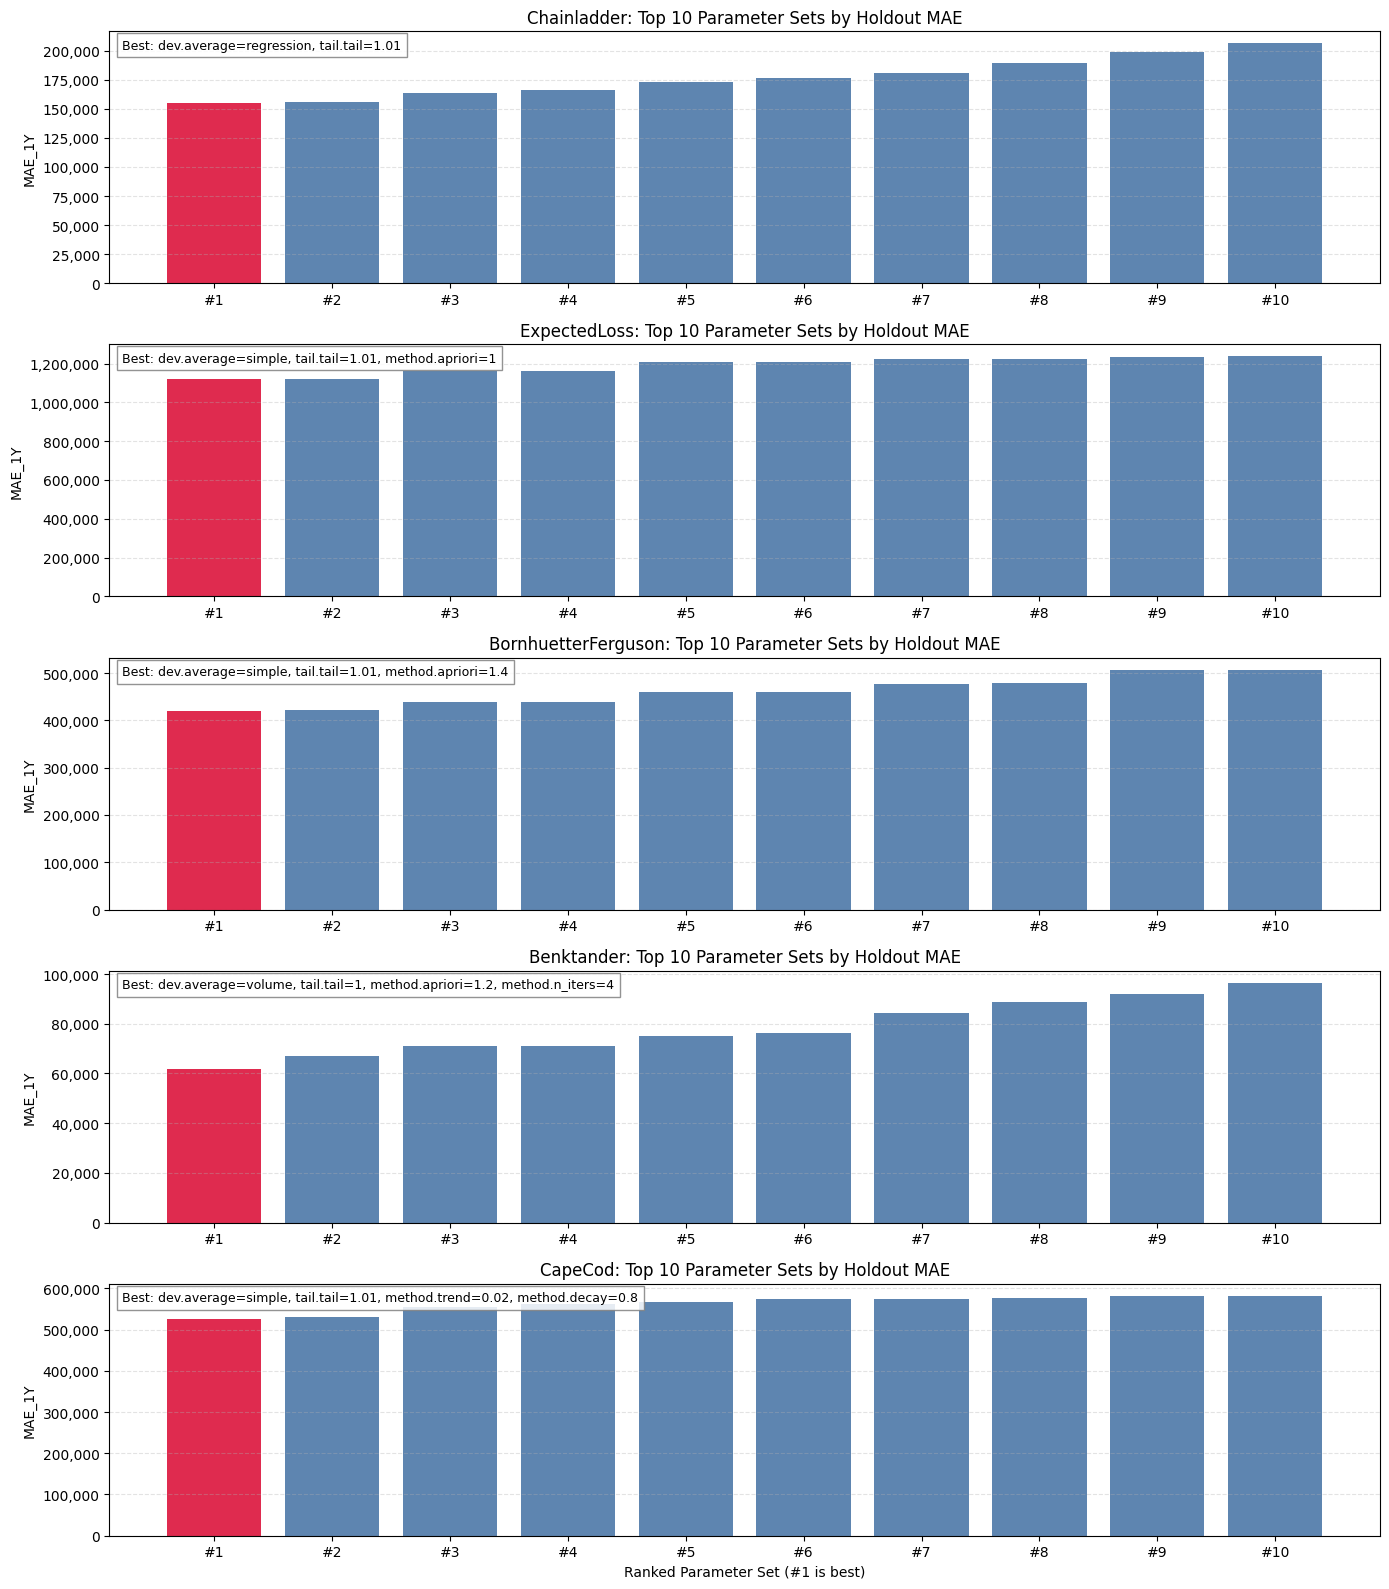

In [68]:
# Multi-method grid search using one-year holdout emergence error as scoring objective.
search_current_valuation = paid_triangle.valuation_date
search_prior_valuation = search_current_valuation - pd.DateOffset(years=1)
search_history_paid = paid_triangle[paid_triangle.valuation <= search_prior_valuation]

search_actual_runoff = paid_triangle.dev_to_val().cum_to_incr()
search_actual_1y = search_actual_runoff[(search_actual_runoff.valuation > search_prior_valuation) & (search_actual_runoff.valuation <= search_current_valuation)]
search_actual_by_ay = search_actual_1y.to_frame().iloc[:, 0].rename('Actual')

def get_method_model(fitted_obj):
    return fitted_obj.named_steps['method'] if hasattr(fitted_obj, 'named_steps') else fitted_obj

def expected_by_ay_for_holdout(fitted_obj):
    method_model = get_method_model(fitted_obj)
    expected_runoff = method_model.full_expectation_.dev_to_val().cum_to_incr()
    expected_1y = expected_runoff[(expected_runoff.valuation > search_prior_valuation) & (expected_runoff.valuation <= search_current_valuation)]
    return expected_1y.to_frame().iloc[:, 0].rename('Expected')

def holdout_compare_frame(fitted_obj):
    expected = expected_by_ay_for_holdout(fitted_obj)
    return pd.concat([search_actual_by_ay, expected], axis=1).dropna()

def mae_1y(fitted_obj):
    cmp = holdout_compare_frame(fitted_obj)
    if cmp.empty:
        return float('nan')
    return float((cmp['Expected'] - cmp['Actual']).abs().mean())

def bias_1y(fitted_obj):
    cmp = holdout_compare_frame(fitted_obj)
    if cmp.empty:
        return float('nan')
    return float((cmp['Expected'] - cmp['Actual']).mean())

def total_ultimate(fitted_obj):
    return float(get_method_model(fitted_obj).ultimate_.sum().sum())

def total_ibnr(fitted_obj):
    return float(get_method_model(fitted_obj).ibnr_.sum().sum())

apriori_history = search_history_paid.latest_diagonal * 1.30
cape_cod_exposure_history = search_history_paid.latest_diagonal.copy()

grid_specs = {
    'Chainladder': {
        'method': cl.Chainladder(),
        'param_grid': {
            'development__average': ['simple', 'volume', 'regression'],
            'tail__tail': [1.00, 1.01, 1.02, 1.03],
        },
        'sample_weight': None,
    },
    'ExpectedLoss': {
        'method': cl.ExpectedLoss(),
        'param_grid': {
            'development__average': ['simple', 'volume'],
            'tail__tail': [1.00, 1.01, 1.02],
            'method__apriori': [0.8, 1.0, 1.2, 1.4],
        },
        'sample_weight': apriori_history,
    },
    'BornhuetterFerguson': {
        'method': cl.BornhuetterFerguson(),
        'param_grid': {
            'development__average': ['simple', 'volume'],
            'tail__tail': [1.00, 1.01, 1.02],
            'method__apriori': [0.8, 1.0, 1.2, 1.4],
        },
        'sample_weight': apriori_history,
    },
    'Benktander': {
        'method': cl.Benktander(),
        'param_grid': {
            'development__average': ['simple', 'volume'],
            'tail__tail': [1.00, 1.01, 1.02],
            'method__apriori': [0.8, 1.0, 1.2],
            'method__n_iters': [1, 2, 3, 4],
        },
        'sample_weight': apriori_history,
    },
    'CapeCod': {
        'method': cl.CapeCod(),
        'param_grid': {
            'development__average': ['simple', 'volume'],
            'tail__tail': [1.00, 1.01, 1.02],
            'method__trend': [-0.02, 0.0, 0.02],
            'method__decay': [0.8, 1.0, 1.2],
        },
        'sample_weight': cape_cod_exposure_history,
    },
}

grid_results_by_method: dict[str, pd.DataFrame] = {}
best_rows = []

for method_name, spec in grid_specs.items():
    estimator = cl.Pipeline(
        steps=[
            ('development', cl.Development()),
            ('tail', cl.TailConstant()),
            ('method', spec['method']),
        ]
    )

    gs = cl.GridSearch(
        estimator=estimator,
        param_grid=spec['param_grid'],
        scoring={
            'MAE_1Y': mae_1y,
            'Bias_1Y': bias_1y,
            'TotalUltimate': total_ultimate,
            'TotalIBNR': total_ibnr,
        },
    )

    if spec['sample_weight'] is None:
        gs.fit(search_history_paid)
    else:
        gs.fit(search_history_paid, sample_weight=spec['sample_weight'])

    results = gs.results_.copy()
    results['AbsBias_1Y'] = results['Bias_1Y'].abs()
    results = results.sort_values(['MAE_1Y', 'AbsBias_1Y'], ascending=[True, True]).reset_index(drop=True)
    results['Rank'] = np.arange(1, len(results) + 1)
    results['Method'] = method_name
    grid_results_by_method[method_name] = results

    best_row = results.iloc[0].to_dict()
    best_rows.append(best_row)

best_grid_selection = pd.DataFrame(best_rows)
best_grid_selection = best_grid_selection.sort_values('MAE_1Y').reset_index(drop=True)

# Keep method + parameter columns + key scores for readability.
score_cols = ['Method', 'MAE_1Y', 'Bias_1Y', 'TotalUltimate', 'TotalIBNR']
param_cols_union = sorted({k for spec in grid_specs.values() for k in spec['param_grid'].keys()})
best_display_cols = [c for c in score_cols + param_cols_union if c in best_grid_selection.columns]
display(best_grid_selection[best_display_cols])

def format_param_string(row: pd.Series, param_cols: list[str]) -> str:
    parts = []
    for col in param_cols:
        if col not in row or pd.isna(row[col]):
            continue
        key = col.replace('development__', 'dev.').replace('tail__', 'tail.').replace('method__', 'method.')
        val = row[col]
        if isinstance(val, float):
            if abs(val) >= 100:
                val_fmt = f"{val:,.0f}"
            else:
                val_fmt = f"{val:.3g}"
        else:
            val_fmt = str(val)
        parts.append(f"{key}={val_fmt}")
    return ', '.join(parts)

n_methods = len(grid_results_by_method)
fig, axes = plt.subplots(n_methods, 1, figsize=(14, 3.2 * n_methods), sharex=False)
if n_methods == 1:
    axes = [axes]

for ax, (method_name, results) in zip(axes, grid_results_by_method.items()):
    top_n = min(10, len(results))
    top = results.head(top_n).copy()
    colors = ['crimson'] + ['#4C78A8'] * (top_n - 1)

    ax.bar(np.arange(top_n), top['MAE_1Y'], color=colors, alpha=0.9)
    ax.set_title(f"{method_name}: Top {top_n} Parameter Sets by Holdout MAE")
    ax.set_ylabel('MAE_1Y')
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.set_xticks(np.arange(top_n))
    ax.set_xticklabels([f"#{i}" for i in range(1, top_n + 1)])

    method_param_cols = list(grid_specs[method_name]['param_grid'].keys())
    best_param_text = format_param_string(top.iloc[0], method_param_cols)
    ax.text(
        0.01,
        0.97,
        f"Best: {best_param_text}",
        transform=ax.transAxes,
        va='top',
        ha='left',
        fontsize=9,
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85),
    )

axes[-1].set_xlabel('Ranked Parameter Set (#1 is best)')
plt.tight_layout()
plt.show()


## Recommended Order of Operations (Exam Workflow)

1. Build triangle.
2. Run diagnostics.
3. Fit development.
4. Apply tail (if needed).
5. Fit reserving method.
6. Extract ultimate and IBNR.
7. Compare alternatives and document judgment.

## Reproducibility Notes

Workflow objects store fitted parameters and keep modeling stages explicit.
This supports:
- auditability,
- reproducibility,
- modular comparison.

Core idea: workflow enforces clean separation among development, tail, and method so assumptions are localized and comparisons are structured.
